# Synthetic inclusion distribution
This notebook simulates distributions of inclusions
- 1. Import dependencies and install packages
- 2. Calculate distributions
- 3. plot 

## 1. Import packages and setup folders and paths

### Import packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import DiadFit as pf
import os
import pickle
from labellines import labelLines
from scipy import stats, signal
import math


mpl.rcParams['pdf.fonttype'] = 42  # 42 is for TrueType fonts

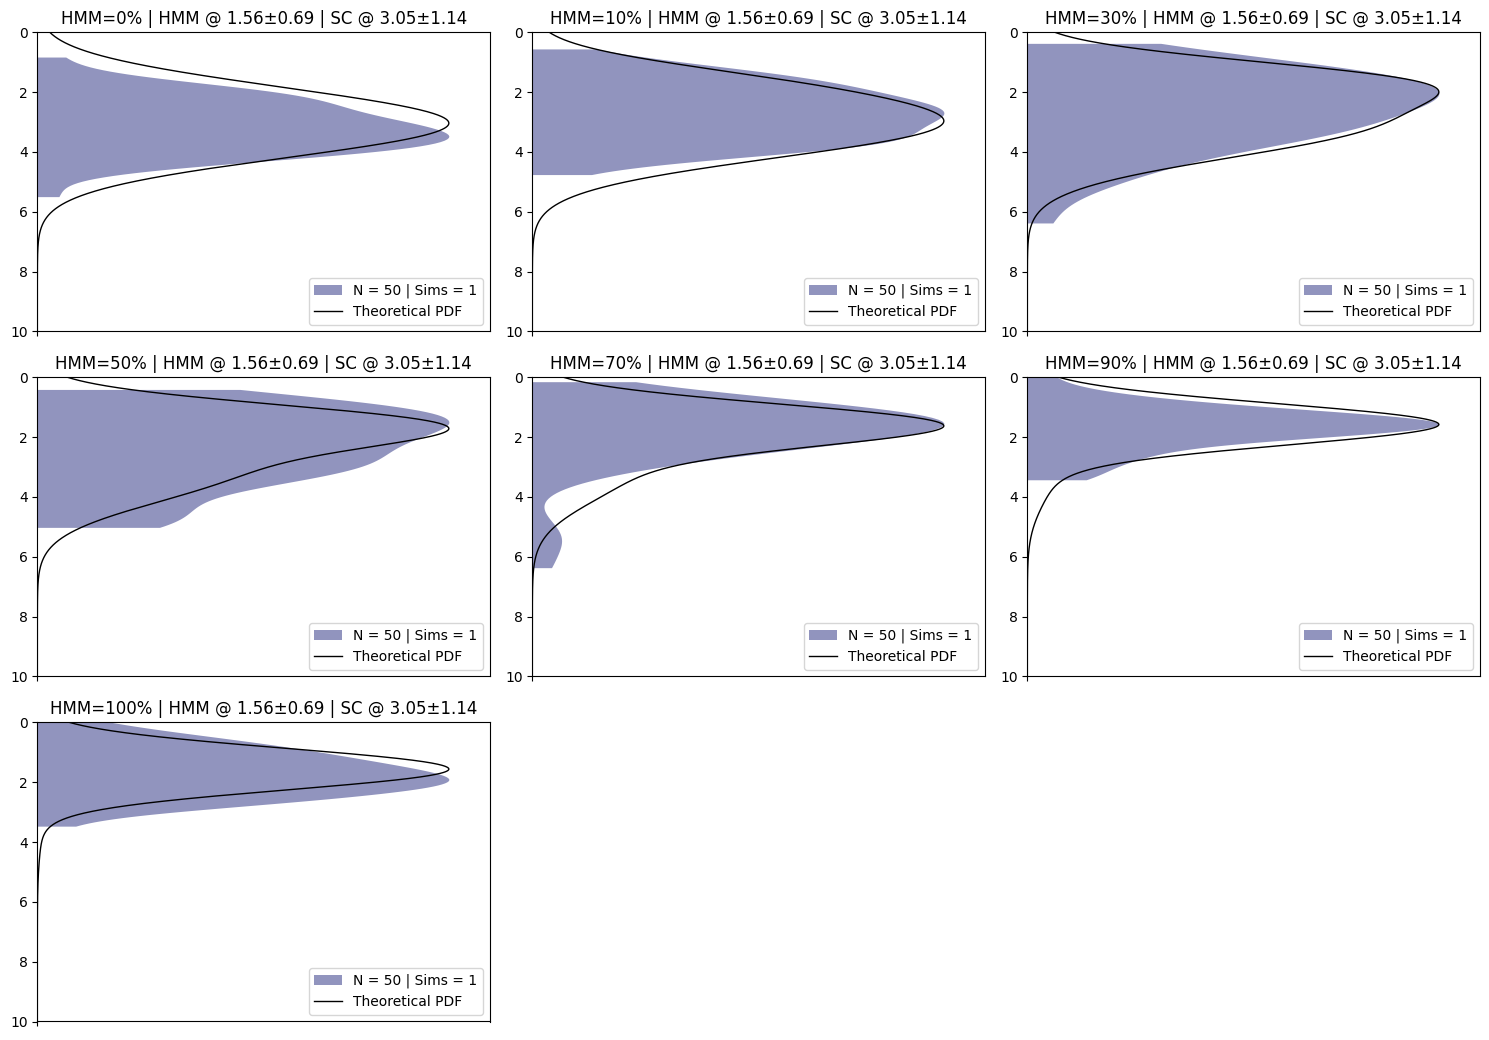

In [58]:
mu1, sigma1 = 1.56, 0.69
mu2, sigma2 = 3.05, 1.14
proportions = [0,0.1, 0.3, 0.5, 0.7, 0.9,1]
N_grid = [10, 20, 50, 100, 200, 500]
rng = np.random.default_rng(42)

ylims = (10, 0)
xs = np.linspace(min(ylims), max(ylims), 2000)

N_total = N_grid[2]
n_sims = 1

results = {}

for p1 in proportions:
    n1 = max(1, int(round(p1 * N_total)))
    n2 = max(1, N_total - n1)
    w1 = n1 / N_total
    w2 = n2 / N_total

    f_true = (w1 * (1.0 / (sigma1 * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((xs - mu1) / sigma1)**2) +
              w2 * (1.0 / (sigma2 * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((xs - mu2) / sigma2)**2))

    mu_mix = w1*mu1 + w2*mu2
    var_mix = w1*(sigma1**2 + mu1**2) + w2*(sigma2**2 + mu2**2) - mu_mix**2
    std_mix = np.sqrt(max(var_mix, 0.0))

    pooled_list = []
    for _ in range(n_sims):
        x1 = rng.normal(mu1, sigma1, size=n1)
        x2 = rng.normal(mu2, sigma2, size=n2)
        pooled = np.concatenate([x1, x2])
        pooled_list.append(pooled)

    all_data = np.concatenate(pooled_list)
    emp_mean = float(np.mean(all_data))
    emp_std = float(np.std(all_data, ddof=1)) if all_data.size > 1 else float(np.std(all_data))
    emp_n = int(all_data.size)


    results[p1] = {
        "data": all_data,
        "mu1": mu1, "sigma1": sigma1,
        "mu2": mu2, "sigma2": sigma2,
        "p1": p1, "p2": 1.0 - p1,
        "n1": n1, "n2": n2,
        "w1": w1, "w2": w2,
        "N_total": N_total,
        "n_sims": n_sims,
        "xs": xs,
        "f_true":f_true,
        "emp_mean": emp_mean,
        "emp_std": emp_std,
        "emp_n": emp_n,
        "theo_mean": float(mu_mix),
        "theo_std": float(std_mix),
        "theo_var": float(var_mix),
    }

n_cols = 3
n_rows = int(np.ceil(len(proportions)/ n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()  
for ax, p1 in zip(axes, proportions):
    r = results[p1]
    data = r["data"]
    w1, w2 = r["w1"], r["w2"]
    mu1, sigma1 = r["mu1"], r["sigma1"]
    mu2, sigma2 = r["mu2"], r["sigma2"]
    f_true = r["f_true"]

    sns.violinplot(y=r['data'],
        ax=ax,inner=None,fill=True,orient='v',cut=0,linewidth=0,color="#898EC5",bw_method='silverman',
        density_norm='area',
    label=f"N = {N_total} | Sims = {n_sims}"
    )

    polys = [c for c in ax.collections if hasattr(c, "get_paths") and c.get_paths()]
    target_half_width = max((np.max(np.abs(p.vertices[:, 0]))
            for p in (polys[0].get_paths() if polys else [])
            if p.vertices.size),default=0.2)
    
    scale_factor = (target_half_width / np.max(f_true)) if np.max(f_true) > 0 else 1.0
    f_theo_scaled = f_true * scale_factor

    ax.plot(f_theo_scaled,xs, color="black", lw=1,label='Theoretical PDF')

    # ax.plot(f_true,xs, color="black", lw=2.5, label="Theoretical PDF")


    ax.set_title(f"HMM={p1*100:.0f}% | HMM @ {mu1}±{sigma1} | SC @ {mu2}±{sigma2}")
    ax.set_xlim(0)
    ax.set_ylim(max(ylims),min(ylims))
    ax.legend(loc='lower right')

for ax in axes[len(proportions):]:
    ax.axis("off")

fig.tight_layout()
plt.show()

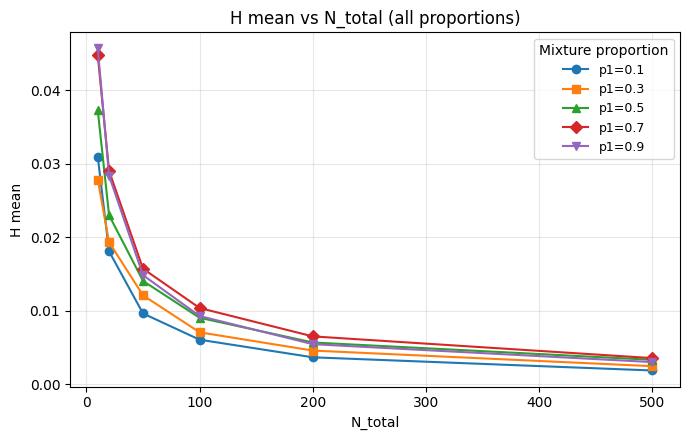

In [59]:

# --- your setup code remains the same up to metric_key ---
mu1, sigma1 = 1.5, 0.5
mu2, sigma2 = 3.0, 1.0
proportions = [0.1, 0.3, 0.5, 0.7, 0.9]
N_grid = [10, 20, 50, 100, 200, 500]
n_sims = 200
rng = np.random.default_rng(123)

x_min = min(mu1 - 6*sigma1, mu2 - 6*sigma2)
x_max = max(mu1 + 6*sigma1, mu2 + 6*sigma2)
xs = np.linspace(x_min, x_max, 2000)
dx = xs[1] - xs[0]

metrics = {p1: {} for p1 in proportions}

eps = 1e-12

for p1 in proportions:
    for N_total in N_grid:
        n1 = max(1, int(round(p1 * N_total)))
        n2 = max(1, N_total - n1)
        w1, w2 = n1 / N_total, n2 / N_total

        f_true = (w1 * (1.0/(sigma1*np.sqrt(2*np.pi))) * np.exp(-0.5*((xs - mu1)/sigma1)**2) +
                  w2 * (1.0/(sigma2*np.sqrt(2*np.pi))) * np.exp(-0.5*((xs - mu2)/sigma2)**2))

        ISEs, L1s, Hs, JSs = [], [], [], []

        for _ in range(n_sims):
            x1 = rng.normal(mu1, sigma1, size=n1)
            x2 = rng.normal(mu2, sigma2, size=n2)
            pooled = np.concatenate([x1, x2])

            kde = stats.gaussian_kde(pooled)
            f_hat = kde(xs)

            norm = np.trapz(f_hat, xs)
            if norm > 0:  # fix HTML entity: &gt; -> >
                f_hat = f_hat / norm

            ISEs.append(np.trapz((f_hat - f_true)**2, xs))
            L1s.append(np.trapz(np.abs(f_hat - f_true), xs))
            Hs.append(0.5 * np.trapz((np.sqrt(np.maximum(f_hat, 0)) - np.sqrt(np.maximum(f_true, 0)))**2, xs))

            m = 0.5 * (f_true + f_hat)
            f_safe = np.maximum(f_true, eps)
            fh_safe = np.maximum(f_hat, eps)
            m_safe = np.maximum(m, eps)
            KL_f_m  = np.trapz(f_safe  * np.log(f_safe  / m_safe), xs)
            KL_fh_m = np.trapz(fh_safe * np.log(fh_safe / m_safe), xs)
            JSs.append(0.5 * (KL_f_m + KL_fh_m))

        metrics[p1][N_total] = {
            "ISE_mean": float(np.mean(ISEs)), "ISE_sd": float(np.std(ISEs, ddof=1)),
            "L1_mean": float(np.mean(L1s)),   "L1_sd": float(np.std(L1s, ddof=1)),
            "H_mean": float(np.mean(Hs)),     "H_sd": float(np.std(Hs, ddof=1)),
            "JS_mean": float(np.mean(JSs)),   "JS_sd": float(np.std(JSs, ddof=1)),
            "n1": n1, "n2": n2
        }

# --- single-axis plotting (no subplots) ---
metric_key = "H_mean"  # or "L1_mean", "ISE_mean", "JS_mean"

fig, ax = plt.subplots(figsize=(7, 4.5))

Ns = np.array(N_grid)

# Optional: distinct styles per proportion
markers = ['o', 's', '^', 'D', 'v']
for i, p1 in enumerate(proportions):
    ys = np.array([metrics[p1][N][metric_key] for N in N_grid])
    ax.plot(Ns, ys,
            marker=markers[i % len(markers)],
            linestyle='-',
            label=f"p1={p1}")

ax.set_title(f"{metric_key.replace('_', ' ')} vs N_total (all proportions)")
ax.set_xlabel("N_total")
ax.set_ylabel(metric_key.replace('_', ' '))
ax.grid(True, alpha=0.3)
ax.legend(title="Mixture proportion", fontsize=9)

plt.tight_layout()
plt.show()
